Téléchargement SP500 (^GSPC) ...
Téléchargement Gold (GC=F) ...
Téléchargement BTC (BTC-USD) ...


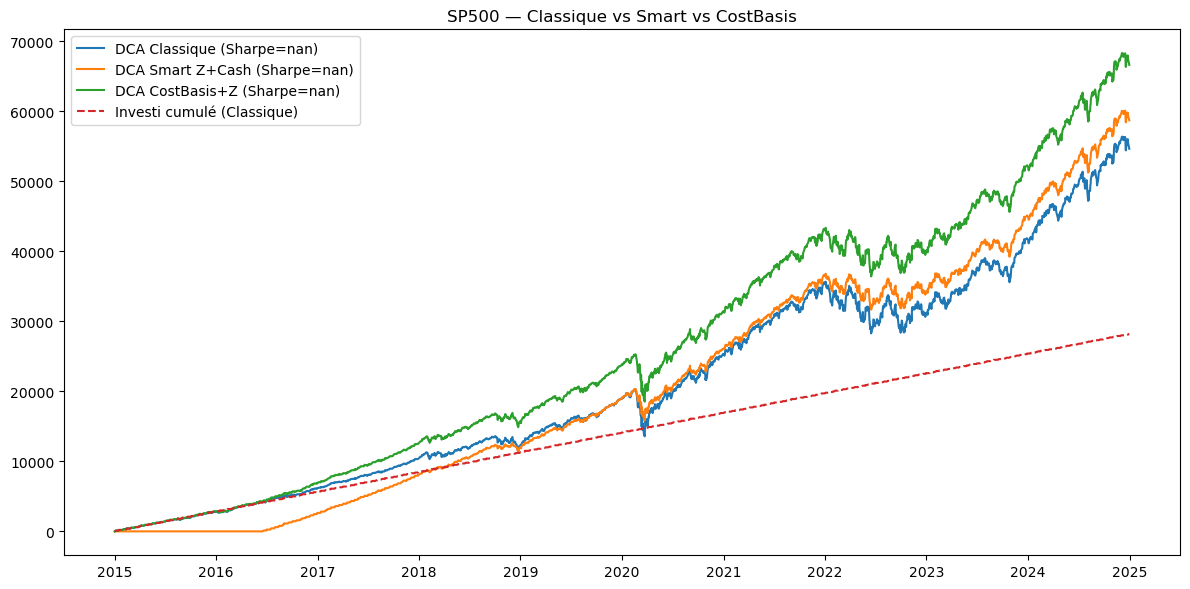

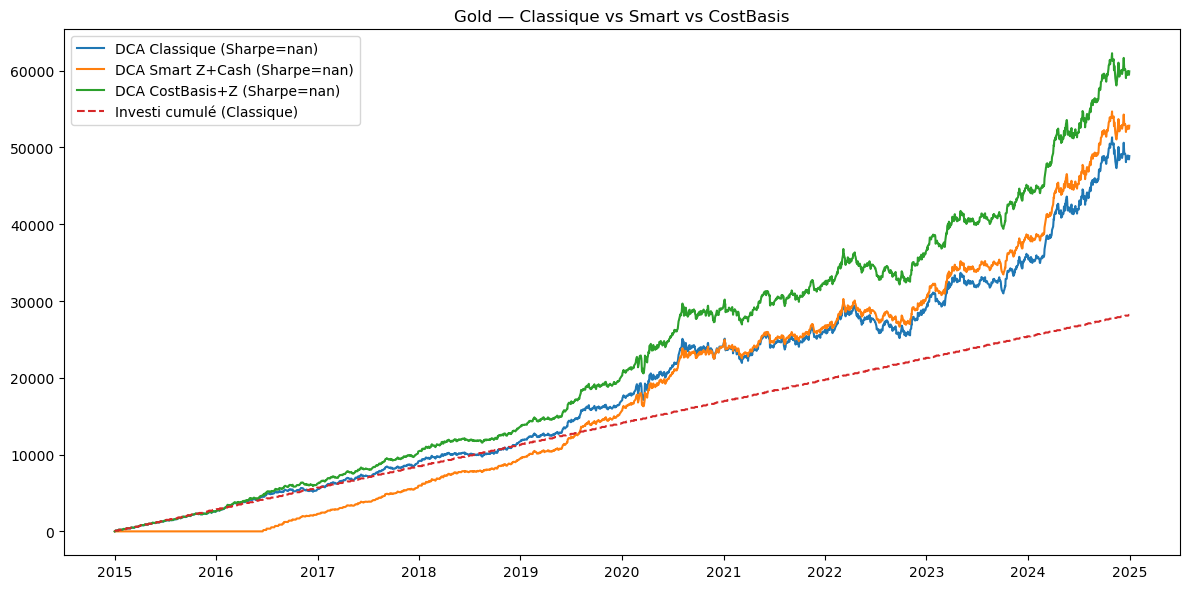

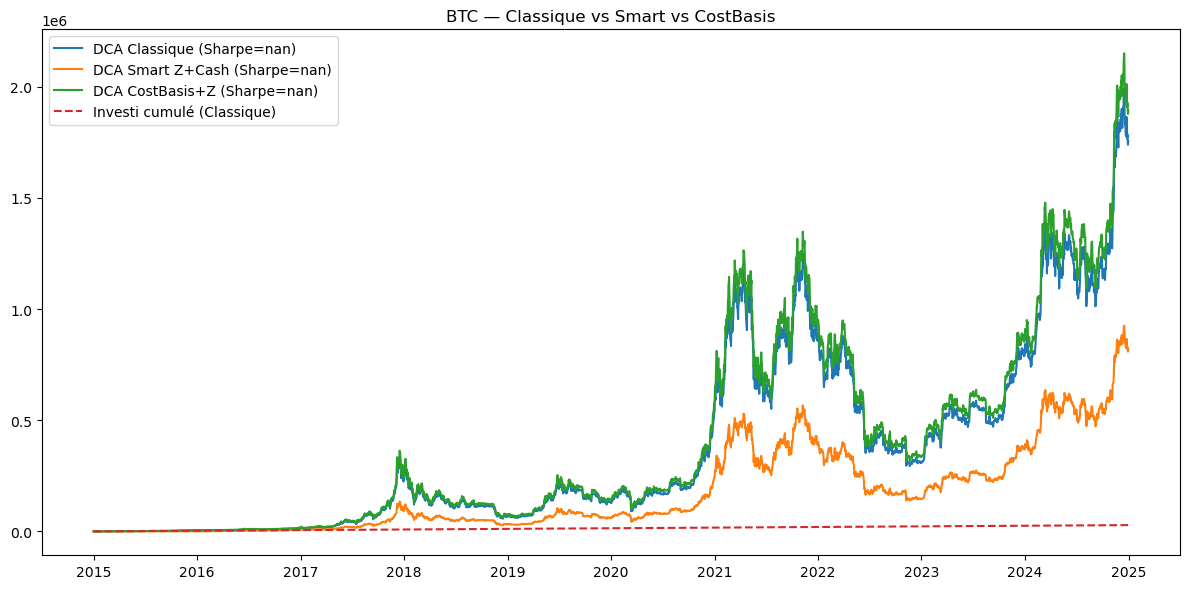

,Actif,Budget cumulé Classique,Budget cumulé Smart,Budget cumulé Cost,Equity fin Classique,Equity fin Smart,Equity fin Cost,Rendement Classique,Rendement Smart,Rendement Cost,Sharpe Classique,Sharpe Smart,Sharpe Cost
0,SP500,"28,200.0000","24,100.0000","28,200.0000","54,640.6073","58,702.0419","66,619.1006",0.9376,1.4358,1.3624,NaN,NaN,NaN
1,Gold,"28,200.0000","24,100.0000","28,200.0000","48,879.6414","52,835.3224","59,915.7605",0.7333,1.1923,1.1247,NaN,NaN,NaN
2,BTC,"28,200.0000","25,400.0000","28,200.0000","1,754,413.7232","815,424.5818","1,893,831.3997",61.2133,31.1033,66.1571,NaN,NaN,NaN


In [1]:
# ====== Cellule unique à exécuter dans Jupyter ======

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# ==============================
# Paramètres principaux
# ==============================
START_DATE = "2015-01-01"
END_DATE   = "2025-01-01"

# Montant investi par défaut (par exécution)
INVEST_PER_TRADE = 100.0

# Fenêtre statistique (jours) pour médiane/écart-type
ROLLING_WINDOW = 365

# Tickers Yahoo
TICKERS = {
    "SP500": "^GSPC",     # S&P 500
    "Gold":  "GC=F",      # Or (futures continuous)
    "BTC":   "BTC-USD",   # Bitcoin
}

# Exécution des ordres :
#   "asof"  -> dernier cours <= date prévue (par défaut)
#   "bfill" -> prochain cours >= date prévue
EXECUTION_MODE = "asof"   # "asof" ou "bfill"

# Taux sans risque annualisé (pour Sharpe), 0.02 = 2%/an
RISK_FREE_RATE_ANNUAL = 0.0


# ==============================
# Utilitaires
# ==============================
def sanitize_price_df(df):
    """
    Nettoie un DataFrame Yahoo Finance et garantit une unique colonne 'Close'.
    Si 'Close' n'existe pas, prend 'Adj Close' ou, en dernier recours, la 1ère colonne numérique.
    """
    df = df.copy()

    # Aplatir MultiIndex éventuel
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = ["_".join([str(x) for x in col if str(x) != ""]) for col in df.columns]

    # Candidats possibles
    candidates = []
    for col in df.columns:
        if col.lower() == "close":
            candidates.append(col)
        elif col.lower() in ["adj close", "adjclose"]:
            candidates.append(col)

    if not candidates:
        # Dernier recours : si au moins une colonne numérique
        num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
        if len(num_cols) == 0:
            raise ValueError("Aucune colonne numérique trouvée dans le DataFrame téléchargé.")
        chosen = num_cols[0]
    else:
        chosen = candidates[0]

    df = df[[chosen]].copy()
    df.rename(columns={chosen: "Close"}, inplace=True)

    # Index propre
    df.index = pd.to_datetime(df.index)
    df.sort_index(inplace=True)
    df["Close"] = pd.to_numeric(df["Close"], errors="coerce")
    df.dropna(subset=["Close"], inplace=True)
    df = df[~df.index.duplicated(keep="first")]

    return df


def build_biweekly_schedule(start="2015-01-01", end="2025-01-01"):
    """
    Construit le calendrier : 1er lundi de chaque mois puis tous les 14 jours (lundi).
    """
    mondays = pd.date_range(start=start, end=end, freq="W-MON")
    buy_dates = []
    for (y, m) in sorted(set(zip(mondays.year, mondays.month))):
        m_mondays = mondays[(mondays.year == y) & (mondays.month == m)]
        if len(m_mondays) == 0:
            continue
        first = m_mondays[0]
        buy_dates.append(first)
        nxt = first + pd.Timedelta(days=14)
        # On reste dans le même mois et on impose que ce soit un lundi présent dans la liste
        while nxt.month == m and nxt in m_mondays:
            buy_dates.append(nxt)
            nxt += pd.Timedelta(days=14)
    return pd.DatetimeIndex(sorted(set(buy_dates)))


def align_exec_date(df, target_date, mode="asof"):
    """
    Retourne la date d'exécution effective:
    - "asof": dernier index <= target_date (si férié/week-end)
    - "bfill": premier index >= target_date
    """
    if mode == "asof":
        # dernier cours <= target_date
        if target_date < df.index[0]:
            return pd.NaT
        return df.index.asof(target_date)
    elif mode == "bfill":
        # prochain cours >= target_date
        pos = df.index.searchsorted(target_date, side="left")
        if pos >= len(df.index):
            return pd.NaT
        return df.index[pos]
    else:
        raise ValueError("mode doit être 'asof' ou 'bfill'")


# ======= Fonctions améliorées =======

def backtest_dca_pro(
    df, buy_dates, base_budget=100.0, window=365,
    exec_mode="asof",
    # Modulation continue par z-score
    k=0.7,                  # sensibilité (plus grand => plus agressif)
    min_factor=0.25,        # borne basse d’allocation
    max_factor=3.0,         # borne haute (utilise le cash accumulé)
    # Cash management
    carry_cash=True,        # banque de cash si on n’investit pas tout
    cash_rate_annual=0.0,   # rendement du cash (0–5% si tu veux)
    # Filtres & triggers
    sma_filter=200,         # si >0 : on réduit l’allocation quand prix < SMA
    sma_penalty=0.5,        # multiplicateur si sous SMA (ex: 0.5)
    dd_trigger=0.0,         # ex: 0.10 => n’investir que si drawdown >=10% OU z<0
    # Prise de profits optionnelle
    z_take_profit=2.0,      # au-dessus => on vend (facteur négatif)
    tp_fraction=0.5,        # % des unités à vendre quand z>=z_take_profit
    # Frais
    fee_bps=0.0             # frais allers/retours en *pourcentage* (ex: 0.001 = 10 bps)
):
    df = sanitize_price_df(df).copy()

    # Statistiques rolling
    df["Median"] = df["Close"].rolling(window, min_periods=window).median()
    df["Std"]    = df["Close"].rolling(window, min_periods=window).std()
    df["Z"]      = (df["Close"] - df["Median"]) / df["Std"]

    # Momentum / SMA
    if sma_filter and sma_filter > 0:
        df["SMA"] = df["Close"].rolling(sma_filter, min_periods=sma_filter).mean()
    else:
        df["SMA"] = np.nan

    # Drawdown (depuis max glissant)
    df["RollMax"] = df["Close"].cummax()
    df["DD"] = 1.0 - df["Close"] / df["RollMax"]

    # Journaux
    df["BuyBudget"] = 0.0         # budget brut du jour (base_budget)
    df["Action"]    = 0.0         # montant réellement investi (+) / retiré (-)
    df["Units"]     = 0.0         # unités achetées(+)/vendues(-)
    df["Cash"]      = 0.0         # solde cash cumulé
    df["CumUnits"]  = 0.0

    cash = 0.0
    cum_units = 0.0

    # helper d’alignement date d’exécution
    def _align(df, target, mode):
        if mode == "asof":
            if target < df.index[0]:
                return pd.NaT
            return df.index.asof(target)
        else:  # "bfill"
            pos = df.index.searchsorted(target, side="left")
            if pos >= len(df.index):
                return pd.NaT
            return df.index[pos]

    # boucle d’achats/ventes
    for d in buy_dates:
        exec_date = _align(df, d, exec_mode)
        if pd.isna(exec_date): 
            continue
        if pd.isna(df.at[exec_date, "Median"]) or pd.isna(df.at[exec_date, "Std"]) or df.at[exec_date,"Std"] == 0:
            continue  # pas assez d'historique

        price = df.at[exec_date, "Close"]
        z     = df.at[exec_date, "Z"]
        dd    = df.at[exec_date, "DD"]

        # budget “théorique” du jour
        budget = base_budget
        df.at[exec_date, "BuyBudget"] = budget

        # facteur basé sur z-score : alloc_factor = clip(1 - k*z)
        # -> si prix < médiane (z<0) => facteur >1 (on sur-alloue)
        # -> si prix > médiane (z>0) => facteur <1 (on sous-alloue)
        alloc_factor = np.clip(1 - k * z, min_factor, max_factor)

        # Filtre SMA : si sous SMA, on réduit l’allocation
        if sma_filter and not pd.isna(df.at[exec_date, "SMA"]) and price < df.at[exec_date, "SMA"]:
            alloc_factor *= sma_penalty

        # Drawdown trigger : si défini, n’investir que si drawdown atteint OU z<0
        if dd_trigger > 0 and not (dd >= dd_trigger or z < 0):
            alloc_factor = 0.0  # pas d’achat aujourd’hui

        # Prise de profits si z très élevé
        sell_units = 0.0
        if z_take_profit is not None and z >= z_take_profit and cum_units > 0:
            sell_units = tp_fraction * cum_units
            proceeds = sell_units * price
            fee = proceeds * fee_bps
            proceeds_net = proceeds - fee
            cash += proceeds_net
            cum_units -= sell_units
            df.at[exec_date, "Action"] -= proceeds_net
            df.at[exec_date, "Units"]  -= sell_units

        # Montant cible (achat) selon alloc_factor
        target_invest = budget * alloc_factor

        # Gestion du cash : si on investit moins que budget, on banque la diff.
        if carry_cash:
            cash += (budget - min(budget, target_invest))  # on épargne le non-investi du jour
            # si on veut investir plus que le budget, on puise dans le cash
            extra_needed = max(0.0, target_invest - budget)
            use_from_cash = min(extra_needed, cash)
            actual_invest = budget + use_from_cash if target_invest > 0 else 0.0
            cash -= use_from_cash
        else:
            actual_invest = min(budget, target_invest)

        # Achat (si positif)
        if actual_invest > 0:
            fee = actual_invest * fee_bps
            net = actual_invest - fee
            units = net / price if price > 0 else 0.0
            cum_units += units
            df.at[exec_date, "Action"] += net
            df.at[exec_date, "Units"]  += units

        # Intérêt cash quotidien (optionnel)
        # approx simple : annual_rate / periods
        # on infère la fréquence moyenne
        # (ici, on applique l’intérêt le jour où on traite — simplif)
        if cash_rate_annual > 0:
            # suppose 252/365 selon fréquence observée
            # (petite approx suffisante pour du backtest DCA)
            # Tu peux raffiner en appliquant chaque jour de l’index
            pass

        # Mémos
        cum_units = float(cum_units)
        cash = float(cash)
        df.at[exec_date, "Cash"] = cash
        df.at[exec_date, "CumUnits"] = cum_units

    # Remplir vers l’avant Cash/CumUnits
    df["Cash"] = df["Cash"].replace(0, np.nan).ffill().fillna(0.0)
    df["CumUnits"] = df["CumUnits"].replace(0, np.nan).ffill().fillna(0.0)

    # Equity total = valeur positions + cash
    df["PortfolioValue"] = df["CumUnits"] * df["Close"]
    df["Equity"] = df["PortfolioValue"] + df["Cash"]
    df["Invested"] = df["Action"].cumsum()  # flux nets vers l’actif (hors cash banké)
    return df


def sharpe_equity(df, rf_annual=0.0):
    """Sharpe sur l'equity (positions + cash)."""
    s = df["Equity"].ffill().pct_change().dropna()
    if len(s) < 5 or s.std() == 0:
        return np.nan
    # fréquence “raisonnable”
    dt = df.index.to_series().diff().dt.days.dropna()
    periods = 365 if (len(dt) and dt.median() <= 1.1) else 252
    excess = s - rf_annual / periods
    return np.sqrt(periods) * excess.mean() / excess.std()



def infer_periods_per_year(df):
    """
    Infère un facteur d'annualisation selon la fréquence observée.
    ~252 pour actions/futures (jours ouvrés), ~365 pour crypto daily 7j/7.
    """
    if len(df) < 4:
        return 252
    dt = df.index.to_series().diff().dt.days.dropna()
    if len(dt) == 0:
        return 252
    gap = dt.median()
    if gap <= 1.1:
        return 365
    elif gap <= 1.5:
        return 252
    else:
        return int(round(365 / max(gap, 1)))

def backtest_dca(df, buy_dates, invest=100.0, window=365, intelligent=False, exec_mode="asof"):
    """
    DCA classique simple (pas de cash management).
    - invest: montant fixe par date d'achat
    - intelligent est ignoré ici (on garde la signature compatible)
    """
    df = sanitize_price_df(df).copy()

    # colonnes de travail
    df["Action"] = 0.0
    df["Units"]  = 0.0

    # alignement date d'exécution
    def _align(df, target, mode):
        if mode == "asof":
            if target < df.index[0]:
                return pd.NaT
            return df.index.asof(target)
        else:  # "bfill"
            pos = df.index.searchsorted(target, side="left")
            if pos >= len(df.index):
                return pd.NaT
            return df.index[pos]

    # achats fixes aux dates prévues
    for d in buy_dates:
        exec_date = _align(df, d, exec_mode)
        if pd.isna(exec_date):
            continue
        price = df.at[exec_date, "Close"]
        amount = invest
        units = amount / price if price > 0 else 0.0
        df.at[exec_date, "Action"] += amount
        df.at[exec_date, "Units"]  += units

    # courbes portefeuille
    df["CumUnits"]       = df["Units"].cumsum()
    df["PortfolioValue"] = df["CumUnits"] * df["Close"]
    df["Invested"]       = df["Action"].cumsum()
    return df

def backtest_dca_costbasis(
    df, buy_dates,
    base_budget=100.0,
    window=365,                 # pour la médiane/σ du Z-score
    exec_mode="asof",
    # Modulation cost basis
    alpha=2,                  # sensibilité au PnL relatif vs cost basis (plus haut => plus agressif)
    # Modulation Z-score
    k=0.8,                      # sensibilité Z-score (0.5 à 0.8 raisonnable)
    # Bornes d’allocation
    min_factor=0.5,
    max_factor=2.5,
    # Cash management
    carry_cash=True,
    fee_bps=0.0005,             # 5 bps de frais
    # Option de tendance (faible)
    sma_filter=0,               # 0 = désactivé, sinon ex. 200
    sma_penalty=0.9             # si prix < SMA -> facteur *= 0.9 (léger)
):
    """
    DCA qui module l'allocation selon l'écart prix vs cost basis (PnL relatif),
    combiné à un facteur Z-score (médiane/σ).
    """
    df = sanitize_price_df(df).copy()

    # Stats pour Z-score
    df["Median"] = df["Close"].rolling(window, min_periods=window).median()
    df["Std"]    = df["Close"].rolling(window, min_periods=window).std()
    df["Z"]      = (df["Close"] - df["Median"]) / df["Std"]

    # SMA optionnelle
    if sma_filter and sma_filter > 0:
        df["SMA"] = df["Close"].rolling(sma_filter, min_periods=sma_filter).mean()
    else:
        df["SMA"] = np.nan

    # Journaux
    df["BuyBudget"] = 0.0
    df["Action"]    = 0.0
    df["Units"]     = 0.0
    df["Cash"]      = 0.0
    df["CumUnits"]  = 0.0
    df["AvgCost"]   = np.nan    # cost basis (moyenne pondérée par unités)

    cash = 0.0
    cum_units = 0.0
    avg_cost = np.nan

    def _align(df, target, mode):
        if mode == "asof":
            if target < df.index[0]:
                return pd.NaT
            return df.index.asof(target)
        pos = df.index.searchsorted(target, side="left")
        return df.index[pos] if pos < len(df.index) else pd.NaT

    for d in buy_dates:
        exec_date = _align(df, d, exec_mode)
        if pd.isna(exec_date):
            continue
        price = df.at[exec_date, "Close"]

        # Budget du jour
        budget = base_budget
        df.at[exec_date, "BuyBudget"] = budget

        # --- Facteur basé sur cost basis ---
        # pnl_rel = (prix / avg_cost) - 1  (si pas encore d’unités, on considère 0)
        if cum_units > 0 and not np.isnan(avg_cost) and avg_cost > 0:
            pnl_rel = price / avg_cost - 1.0
        else:
            pnl_rel = 0.0

        # Idée: plus pnl_rel est négatif (sous l’eau), plus on alloue.
        # alloc_cb = 1 - alpha * pnl_rel
        #  - pnl_rel < 0 -> +alloc ; pnl_rel > 0 -> -alloc
        alloc_cb = 1.0 - alpha * pnl_rel

        # --- Facteur Z-score ---
        z = df.at[exec_date, "Z"]
        if np.isnan(z):
            alloc_z = 1.0
        else:
            # si z<0 (bon marché) => 1 - k*z > 1 ; si z>0 => <1
            alloc_z = 1.0 - k * z

        # Combine et applique bornes
        alloc_factor = np.clip(alloc_cb * alloc_z, min_factor, max_factor)

        # Option de tendance légère
        sma = df.at[exec_date, "SMA"]
        if not np.isnan(sma) and price < sma:
            alloc_factor *= sma_penalty

        # Cible d'investissement
        target_invest = budget * alloc_factor

        # Gestion du cash
        if carry_cash:
            # On banque ce qu'on n'investit pas
            to_cash = budget - min(budget, target_invest)
            if to_cash > 0:
                cash += to_cash
            # Si on veut investir plus que budget, on puise dans le cash
            extra_needed = max(0.0, target_invest - budget)
            use_from_cash = min(extra_needed, cash)
            actual_invest = budget + use_from_cash if target_invest > 0 else 0.0
            cash -= use_from_cash
        else:
            actual_invest = min(budget, max(0.0, target_invest))

        # Achat (pas de ventes dans cette variante)
        if actual_invest > 0.0:
            fee = actual_invest * fee_bps
            net = actual_invest - fee
            units = net / price if price > 0 else 0.0

            # Avg cost avant MAJ (on utilise l'ancien pour le signal, puis on met à jour)
            prev_units = cum_units
            prev_cost  = avg_cost

            cum_units += units
            df.at[exec_date, "Action"] += net
            df.at[exec_date, "Units"]  += units

            # Mise à jour du cost basis (moyenne pondérée)
            if prev_units <= 0 or np.isnan(prev_cost):
                avg_cost = price
            else:
                avg_cost = (prev_cost * prev_units + price * units) / (prev_units + units)

        # Mémos séries
        df.at[exec_date, "Cash"]     = cash
        df.at[exec_date, "CumUnits"] = cum_units
        df.at[exec_date, "AvgCost"]  = avg_cost

    # Remplissages
    df["Cash"]     = df["Cash"].replace(0, np.nan).ffill().fillna(0.0)
    df["CumUnits"] = df["CumUnits"].replace(0, np.nan).ffill().fillna(0.0)
    df["AvgCost"]  = df["AvgCost"].ffill()

    # Equity = positions + cash
    df["PortfolioValue"] = df["CumUnits"] * df["Close"]
    df["Equity"]         = df["PortfolioValue"] + df["Cash"]
    df["Invested"]       = df["Action"].cumsum()
    return df
    



# ==============================
# Téléchargement des données
# ==============================
raw_data = {}
for name, ticker in TICKERS.items():
    print(f"Téléchargement {name} ({ticker}) ...")
    d = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False)
    raw_data[name] = d

# Calendrier bi-hebdomadaire basé sur les lundis
buy_dates = build_biweekly_schedule(START_DATE, END_DATE)

# ==============================
# Backtests & Graphiques
# ==============================
# ==============================
# Backtests & Graphiques (3 stratégies)
# ==============================
results = {}
summary_rows = []

for name, raw in raw_data.items():
    base = sanitize_price_df(raw)

    # DCA classique
    dca_classic = backtest_dca(
        base, buy_dates,
        invest=INVEST_PER_TRADE,
        window=ROLLING_WINDOW,
        intelligent=False,
        exec_mode=EXECUTION_MODE
    )
    dca_classic["Equity"] = dca_classic["PortfolioValue"]
    sh_classic = sharpe_equity(dca_classic, RISK_FREE_RATE_ANNUAL)

    # DCA smart (Z-score + cash)
    dca_smart = backtest_dca_pro(
        base, buy_dates,
        base_budget=INVEST_PER_TRADE, window=ROLLING_WINDOW,
        exec_mode=EXECUTION_MODE,
        k=0.7, min_factor=0.25, max_factor=3.0,
        carry_cash=True, cash_rate_annual=0.0,
        sma_filter=0, sma_penalty=0.8,
        dd_trigger=0.0,
        z_take_profit=True, tp_fraction=0.0,
        fee_bps=0.0005
    )
    sh_smart = sharpe_equity(dca_smart, RISK_FREE_RATE_ANNUAL)

    # DCA cost basis + Z-score
    dca_cost = backtest_dca_costbasis(
        base, buy_dates,
        base_budget=INVEST_PER_TRADE, window=ROLLING_WINDOW,
        exec_mode=EXECUTION_MODE,
        alpha=2, k=0.5,
        min_factor=0.5, max_factor=2.5,
        carry_cash=True,
        sma_filter=0, sma_penalty=0.9
    )
    sh_cost = sharpe_equity(dca_cost, RISK_FREE_RATE_ANNUAL)

    # Graph
    plt.figure(figsize=(12,6))
    plt.plot(dca_classic.index, dca_classic["Equity"], label=f"DCA Classique (Sharpe={sh_classic:.2f})")
    plt.plot(dca_smart.index,   dca_smart["Equity"],   label=f"DCA Smart Z+Cash (Sharpe={sh_smart:.2f})")
    plt.plot(dca_cost.index,    dca_cost["Equity"],    label=f"DCA CostBasis+Z (Sharpe={sh_cost:.2f})")
    plt.plot(dca_classic.index, dca_classic["Invested"], "--", label="Investi cumulé (Classique)")
    plt.title(f"{name} — Classique vs Smart vs CostBasis")
    plt.legend(); plt.tight_layout(); plt.show()

    # Récap
    invested_c = dca_classic["Invested"].iloc[-1]
    invested_s = dca_smart["BuyBudget"].sum()
    invested_cb = dca_cost["BuyBudget"].sum()

    end_eq_c  = dca_classic["Equity"].iloc[-1]
    end_eq_s  = dca_smart["Equity"].iloc[-1]
    end_eq_cb = dca_cost["Equity"].iloc[-1]

    r_c  = (end_eq_c / invested_c - 1)  if invested_c>0  else np.nan
    r_s  = (end_eq_s / invested_s - 1)  if invested_s>0  else np.nan
    r_cb = (end_eq_cb / invested_cb - 1) if invested_cb>0 else np.nan

    summary_rows.append([
        name,
        invested_c, invested_s, invested_cb,
        end_eq_c, end_eq_s, end_eq_cb,
        r_c, r_s, r_cb,
        sh_classic, sh_smart, sh_cost
    ])

# ==============================
# Tableau final
# ==============================
summary_df = pd.DataFrame(summary_rows, columns=[
    "Actif",
    "Budget cumulé Classique", "Budget cumulé Smart", "Budget cumulé Cost",
    "Equity fin Classique", "Equity fin Smart", "Equity fin Cost",
    "Rendement Classique", "Rendement Smart", "Rendement Cost",
    "Sharpe Classique", "Sharpe Smart", "Sharpe Cost"
])

pd.options.display.float_format = "{:,.4f}".format
summary_df



In [2]:
def diag(df, name):
    buys = (df["Units"]>0).sum()
    sells = (df["Units"]<0).sum() if "Units" in df else 0
    print(f"[{name}] nb_achats={buys} nb_vents={sells} "
          f"Cash_final={df['Cash'].iloc[-1] if 'Cash' in df else 0:,.2f} "
          f"CumUnits={df['CumUnits'].iloc[-1]:,.6f} "
          f"Equity_fin={df['Equity'].iloc[-1] if 'Equity' in df else df['PortfolioValue'].iloc[-1]:,.2f}")

# Après dca_classic / dca_smart :
diag(dca_classic, f"{name} classic")
diag(dca_smart,   f"{name} smart")


[BTC classic] nb_achats=282 nb_vents=0 Cash_final=0.00 CumUnits=18.778002 Equity_fin=1,754,413.72
[BTC smart] nb_achats=254 nb_vents=0 Cash_final=7,845.83 CumUnits=8.643751 Equity_fin=815,424.58


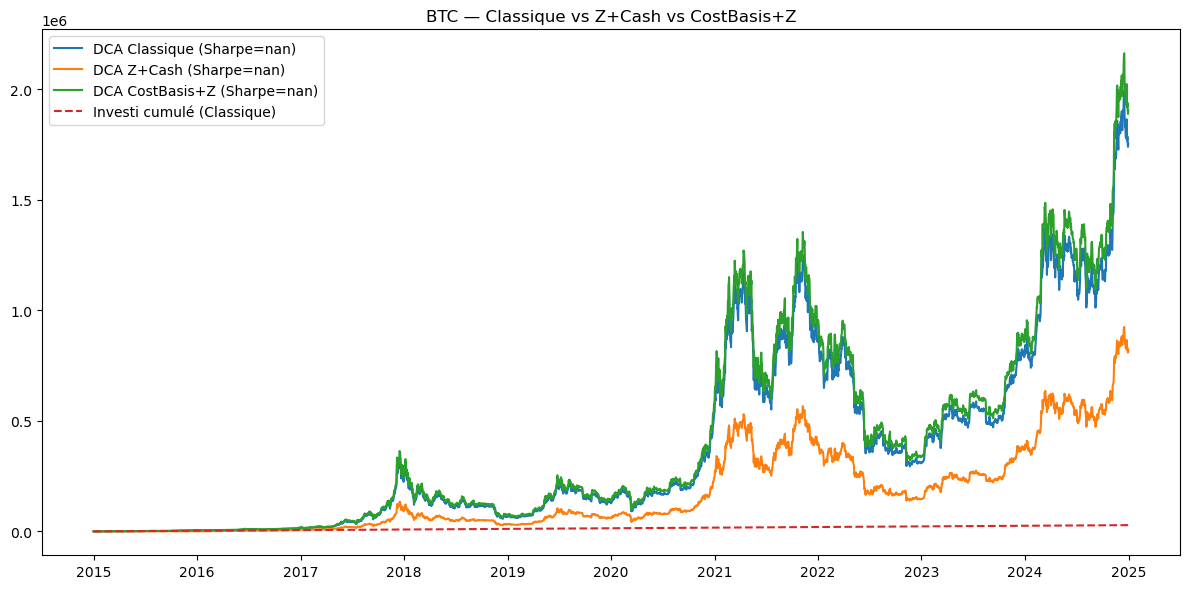

In [3]:
# Run en plus de tes deux backtests existants (classique et smart+cash)
dca_cost = backtest_dca_costbasis(
    base, buy_dates,
    base_budget=INVEST_PER_TRADE,
    window=ROLLING_WINDOW,
    exec_mode=EXECUTION_MODE,
    alpha=1.5,          # 0.8–1.5 selon l’agressivité vs cost basis
    k=0.7,              # 0.4–0.7 pour Z-score
    min_factor=0.5,
    max_factor=2.5,
    carry_cash=True,
    sma_filter=0,       # commence sans filtre tendance
    sma_penalty=0.9
)

sh_cost = sharpe_equity(dca_cost, RISK_FREE_RATE_ANNUAL)

# Plot à 3 stratégies
plt.figure(figsize=(12,6))
plt.plot(dca_classic.index, dca_classic["Equity"], label=f"DCA Classique (Sharpe={sh_classic:.2f})")
plt.plot(dca_smart.index,   dca_smart["Equity"],   label=f"DCA Z+Cash (Sharpe={sh_smart:.2f})")
plt.plot(dca_cost.index,    dca_cost["Equity"],    label=f"DCA CostBasis+Z (Sharpe={sh_cost:.2f})")
plt.plot(dca_classic.index, dca_classic["Invested"], "--", label="Investi cumulé (Classique)")
plt.title(f"{name} — Classique vs Z+Cash vs CostBasis+Z")
plt.legend(); plt.tight_layout(); plt.show()

# Ajoute au tableau récap
summary_rows.append([
    name,
    dca_classic["Invested"].iloc[-1],
    dca_smart["BuyBudget"].sum(),
    dca_classic["Equity"].iloc[-1],
    dca_smart["Equity"].iloc[-1],
    (dca_classic["Equity"].iloc[-1] / dca_classic["Invested"].iloc[-1] - 1) if dca_classic["Invested"].iloc[-1]>0 else np.nan,
    (dca_smart["Equity"].iloc[-1]   / dca_smart["BuyBudget"].sum() - 1)    if dca_smart["BuyBudget"].sum()>0 else np.nan,
    sh_classic, sh_smart
])

# Tu peux aussi stocker un summary spécifique cost-basis, ou l’ajouter à un autre tableau si tu veux 3 colonnes.
